In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pyreadstat
import matplotlib.pyplot as plt

In [2]:
sport_columns = [
    "SPORTCOUNT_A01", "SPORTFUND_A02", "SPORTPRE2016_A03",

    "WALKLEISURE_B01", "WALKTRAV_B02", "CYCLEISSPORT_B03", "CYCTRAV_B04",
    "DANCEART_B05", "FITNESS_B06", "SPORTTRAD_B07", "GARD_B08",

    "WALKALL_C01", "CYCALL_C02", "ACTTRAV_C03", "DANCEALL_C04",
    "TEAMSPORT_C05", "RACKETSPORT_C06", "ADVWATERSPORT_C07", "LEISURE_C08",
    "COMBATTARGET_C09", "WINTER_C10", "RUNATHMULTI_C11", "BOWLSBOULES_C12",
    "GYMTRAMPCHEER_C13", "ROLLER_C14", "INFORMAL_C15",

    "ADVENTURE_D01", "WATERSPORTS_D02", "ATHLETICS_D03",

    "GYM_E01", "FITCLASS_E02", "EXMACHINES_E03", "WEIGHTS_E04",
    "INTSESSION_E05", "GENERICFITNESS_E06",

    "FOOTBALL_F01", "CRICKET_F02", "RUGBYUNION_F03", "RUGBYLEAGUE_F04",
    "WHEELCHRUGBY_F05", "NETBALL_F06", "BASKETBALL_F07",
    "WHEELCHBASKETBALL_F08", "HOCKEY_F09", "VOLLEYBALL_F10",
    "ROUNDERS_F11", "DODGEBALL_F12", "BASESOFTBALL_F13", "LACROSSE_F14",
    "GOALBALL_F15", "HANDBALL_F16",

    "TENNIS_G01", "BADMINTON_G02", "TABLETENNIS_G03", "SQUASH_G04",
    "PICKLEBALL_G05", "PADEL_G06",

    "CAVING_H02", "ABSEILING_H03", "ORIENTEERING_H04", "PARKOUR_H05",
    "ROWING_H06", "SAILING_H07", "GLIDING_H08", "CANOEING_H09",
    "WATERSKIING_H10", "SURFING_H11", "SCUBA_H12", "LIFESAVING_H13",
    "HIGHROPES_H14", "HILLWALK_H15", "CLIMBBOULD_H16",

    "ANGLING_I01", "ICESKATING_I02", "FRISBEE_I03", "TENPIN_I04",
    "CROQUET_I05", "SNOOKER_I06", "POOL_I07", "DARTS_I08",
    "SKITTLES_I09", "ACTPLAY_I10",

    "ARCHERY_J01", "BOXING_J02", "FENCING_J03", "JUDO_J04",
    "TAEKWONDO_J05", "TAICHI_J06", "MARTIAL_J07", "SHOOTING_J08",
    "WRESTLING_J09",

    "SNOWSPORT_K01", "SLEDDING_K02", "ICEHOCKEY_K03",

    "SWIM_L01", "TRACKANDFIELD_L02", "RUNNING_L03", "FELLRUNNING_L04",
    "TRIATHLON_L05", "MODPENT_L06", "OBSTACLE_L07", "GOLF_L08",
    "EQUEST_L09", "BOWLS_L10", "BOCCIA_L11", "BOULES_L12",
    "GYMNASTICS_L13", "GARDENTRAMP_L14", "CHEERLEADING_L15",
    "ROLLERSKATING_L16", "SKATEBOARDING_L17", "MOTORSPORTS_L18",

    "SWIM_OLD_M01", "CYC_OLD_M02", "GOLF_OLD_M03",

    "CYCLEISURE_N01", "CYCMOUNTAIN_N02", "CYCBMX_N03", "CYCROAD_N04",
    "CYCTRACK_N05", "CYCCROSS_N06",

    "DANCEOTHER_O01",

    "PILATES_P01", "YOGA_P02", "BOXCLASS_P03", "CARDIOCLASS_P04",
    "CORECLASS_P05", "CYCLECLASS_P06", "DANCECLASS_P07", "WATERCLASS_P08",
    "WEIGHTSCLASS_P09", "OTHERFITCLASS_P10", "XTRAINMACHINE_P11",
    "EXBIKE_P12", "ROWMACHINE_P13", "STEPMACHINE_P14", "TREADMILL_P15",
    "EXMACHINESOTHER_P16", "RESISTMACHINE_P17", "FREEWEIGHTS_P18",
    "WEIGHTLIFTING_P19", "CIRCUITS_P20", "XTRAINING_P21", "BOOTCAMP_P22",
    "XFIT_P23", "HIIT_P24", "BODYWEIGHT_P25", "SKIPPING_P26", "HULAHOOP_P27",

    "FOOTBALL11_Q01", "FOOTBALLSMALL_Q02", "FUTSAL_Q03", "FOOTBALLWALK_Q04",
    "FOOTBALLOTHER_Q05", "CRICKETLONG_Q06", "CRICKETSHORT_Q07",
    "CRICKETNETPRAC_Q09", "CRICKETOTH_Q12", "RUGBYUN15_Q13",
    "RUGBYUNTOUCH_Q14", "RUGBYUN7_Q15", "RUGBYUNTAG_Q16",
    "RUGBYLEAG13_Q17", "RUGBYLEAGTOUCH_Q18", "RUGBYLEAGTAG_Q19",

    "ROCKCLIMB_R01", "CLIMBWALL_R02", "ROWINGWATER_R04", "MOUNTSCRAM_R05",
    "HILLWALK_R06",

    "BOXINGTRAD_S01", "KARATE_S02", "JUJITSU_S03", "AIKIDO_S04",
    "MARTIALCHINESE_S05", "MARTIALOTHER_S06", "AIRGUN_S08", "RIFLE_S09",
    "SHOTGUN_S10",

    "SKIING_T01", "SNOWBOARDING_T02",

    "SWIMJUST_U01", "SWIMIN_U02", "SWIMOUTPOOL_U03", "SWIMOPEN_U04",
    "DIVING_U05", "WATERPOLO_U06", "RUNJOG_U07", "GOLFFULL_U08",
    "GOLFSHORT_U09", "DRIVINGRANGE_U10", "GOLFADV_U11", "EQUESTHACKING_U12",
    "EQUESTSCHOOLING_U13", "EQUESTSHOWJUMP_U14", "EQUESTDRESSAGE_U15",
    "EQUESTEVENTING_U16", "EQUESTOTHER_U17", "BOWLSCARPET_U18",
    "BOWLSCROWNGREEN_U19", "BOWLSFLATGREEN_U20", "BOWLSFLATGREENIN_U21",
    "BOWLSFLATGREENOUT_U22", "BOWLSSHORTMAT_U23", "GYMNASTICSONLY_U24",
    "TRAMPOLINING_U25", "KARTING_U26", "MOTORCYCRACE_U27",
    "MOTORCARRACE_U28",
]

measure_columns = [
    'FREQUENCY', 'FREQUENCYGR',
    'DURATION', 'DURATIONGR',
    'CLUB'
]

sport_dict = {
    9288 : {
        'start' : 2022,
        'end' : 2023,
        'range' : '22-23',
        'year_num' : 'year_8',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\9288_ActiveLifeSurvey_2022_2023\UKDA-9288-spss\spss\spss28\active_lives_survey_nov_22-23_data_year_8_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\9288_ActiveLifeSurvey_2022_2023\UKDA-9288-spss\mrdoc\excel\9288_active_lives_survey_year_8_code_book.xlsx")

    },
    9136 : {
        'start' : 2021,
        'end' : 2022,
        'range' : '21-22',
        'year_num' : 'year_7',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\9136_ActiveLifeSurvey_2021_2022\UKDA-9136-spss\spss\spss28\active_lives_survey_nov_21-22_data_year_7_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\9136_ActiveLifeSurvey_2021_2022\UKDA-9136-spss\mrdoc\excel\9136_active_lives_survey_year_7_code_book.xlsx")
    },
    8993 : {
        'start' : 2020,
        'end': 2021,
        'range' : '20-21',
        'year_num' : 'year_6',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\8993_ActiveLifeSurvey_2020_2021\UKDA-8993-spss\spss\spss28\active_lives_survey_nov_20-21_data_year_6_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\8993_ActiveLifeSurvey_2020_2021\UKDA-8993-spss\mrdoc\excel\8993_active_lives_survey_full_year_6_code_book_final.xlsx")
    },
    8899 : {
        'start' : 2019,
        'end': 2020,
        'range' : '19-20',
        'year_num' : 'year_5',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\8899_ActiveLifeSurvey_2019_2020\UKDA-8899-spss\spss\spss28\active_lives_survey_nov_19-20_data_year_5_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\8899_ActiveLifeSurvey_2019_2020\UKDA-8899-spss\mrdoc\excel\8899_active_lives_adult_code_book_full_year_5_2019-20.xlsx")
    },
    8652 : {
        'start' : 2018,
        'end': 2019,
        'range': '18-19',
        'year_num' : 'year_4',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\8652_ActiveLifeSurvey_2018_2019\UKDA-8652-spss\spss\spss28\active_lives_survey_nov_18-19_data_year_4_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\8652_ActiveLifeSurvey_2018_2019\UKDA-8652-spss\mrdoc\excel\8652_active_lives_adult_code_book_full_year_4.xlsx")
    },
    8651 : {
        'start' : 2017,
        'end' : 2018,
        'range' : '17-18',
        'year_num' : 'year_3',
        'fid' : '20250103',
        'data_path' : Path(r"C:\Masters\London Sport\8651_ActiveLifeSurvey_2017_2018\UKDA-8651-spss\spss\spss28\active_lives_survey_nov_17-18_data_year_3_shared_20250103.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\8651_ActiveLifeSurvey_2017_2018\UKDA-8651-spss\mrdoc\excel\8651_active_lives_adult_code_book_full_year_3_nov_17-18_final.xlsx")
    },
    8391 : {
        'start' : 2016,
        'end' : 2017,
        'range' : '16-17',
        'year_num' : 'year_2',
        'fid' : '20250106',
        'data_path' : Path(r"C:\Masters\London Sport\8391_ActiveLifeSurvey_2016_2017\UKDA-8391-spss\spss\spss28\active_lives_survey_nov_16-17_data_year_2_shared_20250106.sav"),
        'codebook_path' : Path(r"C:\Masters\London Sport\8391_ActiveLifeSurvey_2016_2017\UKDA-8391-spss\mrdoc\excel\8391_active_lives_adult_codebook.xlsx")
    }
    
}

def query_col(col_name : str, meta : pyreadstat.metadata_container) -> str:
    names = meta.column_names
    idx = names.index(col_name)
    return meta.column_labels[idx]

def get_df(path: Path, cols):
    if 'LondInOut' not in cols:
        cols.append('LondInOut')
    df , meta = pyreadstat.read_sav(path, usecols = cols)
    df = df[df['LondInOut'].notna()]
    return df, meta

def retrieve_clean(cols : list[str], data_path :str, table_dict : dict) -> pd.DataFrame:
    master_df = []
    verify_check = verify_paths(data_path, table_dict)
    if len(verify_check) > 0:
        raise FileNotFoundError(f'FilesNotFound:\n{verify_check}')
    print('All Files Found!')
    for k, v in table_dict.items():

        data_pathf = data_path.format(
            a = k,
            b = v['start'],
            c = v['end'],
            d = v['range'],
            e = v['year_num'],
            f = v['fid']
        )
        full_path = Path(data_pathf)

        df, meta = get_df(full_path, cols)

        for i in cols:
            if i not in df.columns:
                print(f'Column not found in {v['start']} - {v['end']} df: {i}')
        df['year'] = f'{v['start']} - {v['end']}'
        master_df.append(df)
        print(f'Retrieved data for: {v['start']} - {v['end']}')
    combined = pd.concat(master_df)
    return combined, meta

def verify_paths(path : str, table_dict : dict) -> list:
    filesnotfound = []
    for k, v in table_dict.items():
        pathf = path.format(
            a = k,
            b = v['start'],
            c = v['end'],
            d = v['range'],
            e = v['year_num'],
            f = v['fid']
        )
  
        outcome = Path(pathf).exists()
        if outcome == False:
            filesnotfound.append(pathf)
        continue
    return filesnotfound

def get_inconsistent_activities(sports_dict):
    dfs = []
    truth_path = list(sport_dict.items())[-1][1]['codebook_path']
    df = pd.read_excel(truth_path, sheet_name ='Activity composites')
    truth_data = df['DV suffix'].values
    for k, v in list(sports_dict.items())[:-1]:
        df = pd.read_excel(v['codebook_path'], sheet_name ='Activity composites')
        data = df['DV suffix'].values
        missing = [c for c in data if c not in truth_data]
        print(f'Dataset {v['year_num']} has {len(missing)} inconsistent vars')
        print(f'Vars:\n>>>{missing}')

def get_df(data_dict):
    df = pd.pyreadstat(data_dict['codebook_path'])

In [3]:
get_inconsistent_activities(sport_dict)

Dataset year_8 has 9 inconsistent vars
Vars:
>>>['INFORMAL_C15', 'PICKLEBALL_G05', 'PADEL_G06', 'HILLWALK_H15', 'CLIMBBOULD_H16', 'ACTPLAY_I10', 'MOUNTSCRAM_R05', 'HILLWALK_R06', 'SHOTGUN_S10']
Dataset year_7 has 5 inconsistent vars
Vars:
>>>['HILLWALK_H15', 'CLIMBBOULD_H16', 'MOUNTSCRAM_R05', 'HILLWALK_R06', 'SHOTGUN_S10']
Dataset year_6 has 5 inconsistent vars
Vars:
>>>['HILLWALK_H15', 'CLIMBBOULD_H16', 'MOUNTSCRAM_R05', 'HILLWALK_R06', 'SHOTGUN_S10']
Dataset year_5 has 5 inconsistent vars
Vars:
>>>['HILLWALK_H15', 'CLIMBBOULD_H16', 'MOUNTSCRAM_R05', 'HILLWALK_R06', 'SHOTGUN_S10']
Dataset year_4 has 5 inconsistent vars
Vars:
>>>['HILLWALK_H15', 'CLIMBBOULD_H16', 'MOUNTSCRAM_R05', 'HILLWALK_R06', 'SHOTGUN_S10']
Dataset year_3 has 4 inconsistent vars
Vars:
>>>['HILLWALK_H15', 'CLIMBBOULD_H16', 'MOUNTSCRAM_R05', 'HILLWALK_R06']


In [4]:
def get_sport_names(sport_dict) -> list[str]:
    sports = []
    measures = 'FREQUENCY'
    truth_path = list(sport_dict.items())[-1][1]['codebook_path']
    df = pd.read_excel(truth_path, sheet_name ='Activity composites')
    dv_suffix = df['DV suffix'].values
    for suffix in dv_suffix:
        full = f'{measures}_{suffix}'
        sports.append(full)
    return sports

sports = get_sport_names(sport_dict)

In [5]:
truth_path = list(sport_dict.items())[-1][1]['codebook_path']

In [6]:
data_path = list(sport_dict.items())[-1][1]['data_path']

In [7]:
# need year, serial number for joining ect + need to confirm preprocessing steps
extra_cols = ['LondInOut']
df, meta = pyreadstat.read_sav(data_path, usecols = sports + extra_cols)
df = df[df['LondInOut'].notna()]

In [8]:
df.head()

,LondInOut,FREQUENCY_SPORTCOUNT_A01,FREQUENCY_SPORTFUND_A02,FREQUENCY_SPORTPRE2016_A03,FREQUENCY_WALKLEISURE_B01,FREQUENCY_WALKTRAV_B02,FREQUENCY_CYCLEISSPORT_B03,FREQUENCY_CYCTRAV_B04,FREQUENCY_DANCEART_B05,FREQUENCY_FITNESS_B06,...,FREQUENCY_EQUESTOTHER_U17,FREQUENCY_BOWLSCARPET_U18,FREQUENCY_BOWLSCROWNGREEN_U19,FREQUENCY_BOWLSFLATGREEN_U20,FREQUENCY_BOWLSSHORTMAT_U23,FREQUENCY_GYMNASTICSONLY_U24,FREQUENCY_TRAMPOLINING_U25,FREQUENCY_KARTING_U26,FREQUENCY_MOTORCYCRACE_U27,FREQUENCY_MOTORCARRACE_U28
12,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25,1.0,4.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,2.0,34.0,34.0,27.0,7.0,0.0,0.0,0.0,0.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48,2.0,3.0,3.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49,2.0,4.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# df.to_csv('sports_data.csv', index=False)

In [10]:
sports_path = Path(r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\sports_data.csv')
sports = pd.read_csv(sports_path)

In [14]:
x = (sports['FREQUENCY_SPORTCOUNT_A01'] !=0).sum()

In [15]:
x

np.int64(17229)

In [ ]:
non_zeros = (sports != 0).sum()

In [12]:
non_zeros

LondInOut                       19497
FREQUENCY_SPORTCOUNT_A01        17229
FREQUENCY_SPORTFUND_A02         15207
FREQUENCY_SPORTPRE2016_A03      11651
FREQUENCY_WALKLEISURE_B01       11062
                                ...  
FREQUENCY_GYMNASTICSONLY_U24       46
FREQUENCY_TRAMPOLINING_U25         69
FREQUENCY_KARTING_U26               2
FREQUENCY_MOTORCYCRACE_U27          1
FREQUENCY_MOTORCARRACE_U28          0
Length: 199, dtype: int64

(array([145.,  18.,   8.,   3.,   3.,   3.,   4.,   1.,   0.,   1.,   0.,
          1.,   1.,   0.,   0.,   0.,   0.,   2.,   0.,   1.,   1.,   2.,
          1.,   1.,   1.,   0.,   1.,   0.,   0.,   1.]),
 array([    0. ,   649.9,  1299.8,  1949.7,  2599.6,  3249.5,  3899.4,
         4549.3,  5199.2,  5849.1,  6499. ,  7148.9,  7798.8,  8448.7,
         9098.6,  9748.5, 10398.4, 11048.3, 11698.2, 12348.1, 12998. ,
        13647.9, 14297.8, 14947.7, 15597.6, 16247.5, 16897.4, 17547.3,
        18197.2, 18847.1, 19497. ]),
 <BarContainer object of 30 artists>)

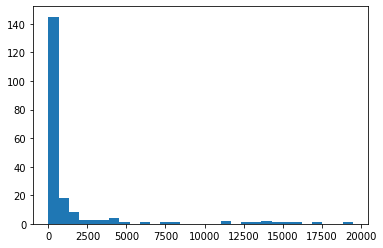

In [13]:
plt.hist(non_zeros, bins=30)

In [ ]:
class FullSportTree:
    def __init__(self, df : pd.DataFrame, measure: str):
        self.df = df
        self.measure = measure
        self.tree = {
          'WALKALL_C01' : {
               'description' : 'Walking All',
               'num_non_zero' : self.get_non_zero('WALKALL_C01'),
               'children' : {
                    'WALKLEISURE_B01' : {
                         'description' : 'Walking for leisure',
                         'num_non_zero' : self.get_non_zero('WALKLEISURE_B01'),
                         'children' : {}
                    }},
                    'WALKTRAV_B02' : {
                         'description' : 'Walking for travel',
                         'num_non_zero' : self.get_non_zero('WALKTRAV_B02'),
                         'children' : {}
                    }},
          'CYCALL_C02': {
               'description' : 'Cycling All',
               'num_non_zero' : self.get_non_zero('CYCALL_C02'),
               'children' : {

               'CYCLEISSPORT_B03' : {
                    'description' : 'Cycling for leisure and sport',
                    'num_non_zero' : self.get_non_zero('CYCLEISSPORT_B03'),
                    'children' : {

                    'CYCLEISURE_N01' : {
                              'description' : 'Cycling for leisure',
                              'num_non_zero' : self.get_non_zero('CYCLEISURE_N01'),
                              'children' : {}
                         },

                         'CYCMOUNTAIN_N02' : {
                              'description' : 'Mountain biking',
                              'num_non_zero' : self.get_non_zero('CYCMOUNTAIN_N02'),
                              'children' : {}
                         },

                         'CYCBMX_N03' : {
                              'description' : 'BMX',
                              'num_non_zero' : self.get_non_zero('CYCBMX_N03'),
                              'children' : {}                                
                         },

                         'CYCROAD_N04' : {
                              'description' : 'Road cycling',
                              'num_non_zero' : self.get_non_zero('CYCROAD_N04'),
                              'children' : {}
                         },

                         'CYCTRACK_N05' : {
                              'description' : 'Track cycling',
                              'num_non_zero' : self.get_non_zero('CYCTRACK_N05'),
                              'children' : {}
                         },

                         'CYCCROSS_N06' : {
                              'description' : 'Cyclo-Cross',
                              'num_non_zero' : self.get_non_zero('CYCCROSS_N06'),
                              'children' : {}
                         }},

               'CYCTRAV_B04' : {
                    'description' : 'Cycling for travel',
                    'num_non_zero' : self.get_non_zero('CYCTRAV_B04'),
                    'children' : {}
                    },
          
          'ACTTRAV_C03' : {
               'description' : 'Active travel (walking or cycling)',
               'num_non_zero' : self.get_non_zero('ACTTRAV_C03'),
               'children' : {} # technically children here should be 

          }

                           
               }
          },
          },
                        
                        
                        
                        
                        }
    def get_non_zero(self, var_name) -> int:
            """Returns the proportion of non zero values"""
            full_name = f'{self.measure}_{var_name}'
            num = (self.df[full_name] != 0).sum()
            return int(num)/len(self.df)
    def get_tree(self):
         return self.tree

In [ ]:
tree = FullSportTree(sports, 'FREQUENCY')
tree.get_tree()

{'WALKALL_C01': {'description': 'Walking All',
  'num_non_zero': 0.816022977894035,
  'children': {'WALKLEISURE_B01': {'description': 'Walking for leisure',
    'num_non_zero': 0.5673693388726471,
    'children': {}}},
  'WALKTRAV_B02': {'description': 'Walking for travel',
   'num_non_zero': 0.6573318972149561,
   'children': {}}},
 'CYCALL_C02': {'description': 'Cycling All',
  'num_non_zero': 0.21003231266348668,
  'children': {'CYCLEISSPORT_B03': {'description': 'Cycling for leisure and sport',
    'num_non_zero': 0.16797456018874699,
    'children': {'CYCLEISURE_N01': {'description': 'Cycling for leisure',
      'num_non_zero': 0.07437041596142996,
      'children': {}},
     'CYCMOUNTAIN_N02': {'description': 'Mountain biking',
      'num_non_zero': 0.0057957634507873005,
      'children': {}},
     'CYCBMX_N03': {'description': 'BMX',
      'num_non_zero': 0.0008206390726778479,
      'children': {}},
     'CYCROAD_N04': {'description': 'Road cycling',
      'num_non_zero': 0.01

In [48]:
class MainSportTree:
    def __init__(self, df : pd.DataFrame, measure : str):
        self.df = df
        self.measure = measure
        self.tree = {
            'WALKALL_C01' : {
                'description' : 'Walking (All)',
                'num_non_zero' : self.get_non_zero('WALKALL_C01'),
                'children' : {
                    'WALKLEISURE_B01' : {
                        'description' : 'Walking (Leisure)',
                        'num_non_zero' : self.get_non_zero('WALKLEISURE_B01'),
                        'children' : {}
                    },
                    'WALKTRAV_B02' : {
                        'description' : 'Walking (Travel)',
                        'num_non_zero' : self.get_non_zero('WALKTRAV_B02'),
                        'children' : {}
                    }
                }
            },
            'CYCALL_C02': {
               'description' : 'Cycling All',
               'num_non_zero' : self.get_non_zero('CYCALL_C02'),
               'children' : {

               'CYCLEISSPORT_B03' : {
                    'description' : 'Cycling for leisure and sport',
                    'num_non_zero' : self.get_non_zero('CYCLEISSPORT_B03'),
                    'children' : {}
               },
               'CYCTRAV_B04' : {
                    'description' : 'Cycling for travel',
                    'num_non_zero' : self.get_non_zero('CYCTRAV_B04'),
                    'children' : {}
                    }
                }
            },
            'FITNESS_B06' : {
                'description' : 'Fitness',
                'num_non_zero' : self.get_non_zero('FITNESS_B06'),
                'children' : {}

            },
            'TEAMSPORT_C05' : {
                'descritpion' : 'Team Sports',
                'num_non_zero' : self.get_non_zero('TEAMSPORT_C05'),
                'children' : {}
            },
            'RACKETSPORT_C06' : {
                'description' : 'Racket Sports',
                'num_non_zero' : self.get_non_zero('RACKETSPORT_C06'),
                'children' : {}
            },
            'GOLF_L08' : {
                'description' : 'Golf',
                'num_non_zero' : self.get_non_zero('GOLF_L08'),
                'children' : {}
            },
            'GARD_B08' : {
                'description' : 'Gardening',
                'num_non_zero' : self.get_non_zero('GARD_B08'),
                'children' : {}
            },
            'LEISURE_C08' : {
                'description' : 'Leisure activities',
                'num_non_zero' : self.get_non_zero('LEISURE_C08'),
                'children' : {}
            }
        }
    def get_non_zero(self, var_name) -> int:
            """Returns the proportion of non zero values"""
            full_name = f'{self.measure}_{var_name}'
            num = (self.df[full_name] != 0).sum()
            return int(num)/len(self.df)
    def get_tree(self):
         return self.tree


In [49]:
tree = MainSportTree(sports, 'FREQUENCY')

In [50]:
tree.get_tree()

{'WALKALL_C01': {'description': 'Walking (All)',
  'num_non_zero': 0.816022977894035,
  'children': {'WALKLEISURE_B01': {'description': 'Walking (Leisure)',
    'num_non_zero': 0.5673693388726471,
    'children': {}},
   'WALKTRAV_B02': {'description': 'Walking (Travel)',
    'num_non_zero': 0.6573318972149561,
    'children': {}}}},
 'CYCALL_C02': {'description': 'Cycling All',
  'num_non_zero': 0.21003231266348668,
  'children': {'CYCLEISSPORT_B03': {'description': 'Cycling for leisure and sport',
    'num_non_zero': 0.16797456018874699,
    'children': {}},
   'CYCTRAV_B04': {'description': 'Cycling for travel',
    'num_non_zero': 0.10334923321536647,
    'children': {}}}},
 'FITNESS_B06': {'description': 'Fitness',
  'num_non_zero': 0.38564907421654615,
  'children': {}},
 'TEAMSPORT_C05': {'descritpion': 'Team Sports',
  'num_non_zero': 0.06877981227881212,
  'children': {}},
 'RACKETSPORT_C06': {'description': 'Racket Sports',
  'num_non_zero': 0.07749910242601425,
  'children':